*Jakub Kobus 283969*
# Sprawozdanie z listy drugiej

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style = "whitegrid")

saDF = pd.read_csv("sa_bruteforce_test.csv")
tsDF = pd.read_csv("ts_bruteforce_test.csv")

display(saDF.head(10))
display(tsDF.head(10))

,file,initialTemperature,alpha,epochs,stepsPerEpoch,avgLength,bestLength
0,wi29.tsp,100,0.8,1000,7,28715.6,27601.2
1,wi29.tsp,100,0.8,1000,14,28545.2,27601.2
2,wi29.tsp,100,0.8,1000,29,28488.1,27601.2
3,wi29.tsp,100,0.8,1000,58,28695.0,27748.7
4,wi29.tsp,100,0.8,5000,7,28631.3,27601.2
5,wi29.tsp,100,0.8,5000,14,28557.7,27601.2
6,wi29.tsp,100,0.8,5000,29,28740.5,27601.2
7,wi29.tsp,100,0.8,5000,58,28569.4,27601.2
8,wi29.tsp,100,0.8,10000,7,28521.8,27601.2
9,wi29.tsp,100,0.8,10000,14,28715.2,27601.2


,file,tabuSize,maxIterations,sampleSize,avgLength,bestLength
0,wi29.tsp,2,1000,7,35673.0,32267.1
1,wi29.tsp,2,1000,14,30214.4,28777.6
2,wi29.tsp,2,1000,29,28052.7,27601.2
3,wi29.tsp,2,1000,58,27617.6,27601.2
4,wi29.tsp,2,5000,7,33828.2,31683.4
5,wi29.tsp,2,5000,14,29282.0,28245.9
6,wi29.tsp,2,5000,29,27723.5,27601.2
7,wi29.tsp,2,5000,58,27601.2,27601.2
8,wi29.tsp,2,10000,7,33504.8,30916.6
9,wi29.tsp,2,10000,14,29075.3,28415.9


In [14]:
def getN(filename):
    match = re.search(r"\d+", filename)
    return int(match.group()) if match else 1

def snap(val, allowed):
    return min(allowed, key=lambda x: abs(x - val))

In [17]:
saDF['N'] = saDF["file"].apply(getN)
tsDF['N'] = tsDF["file"].apply(getN)

saStepsMults   = [0.25,   0.5, 1.0, 2.0]
tsTabuMults    = [0.025, 0.05, 0.1, 0.2, 0.5]
tsSamplesMults = [0.25,   0.5, 1.0, 2.0]


saDF['stepsMult']  = (saDF['stepsPerEpoch'] / saDF['N']).apply(lambda x: snap(x,   saStepsMults))
tsDF['tabuMult']   = (tsDF['tabuSize']      / tsDF['N']).apply(lambda x: snap(x,    tsTabuMults))
tsDF['sampleMult'] = (tsDF['sampleSize']    / tsDF['N']).apply(lambda x: snap(x, tsSamplesMults))

saDF = saDF.sort_values('N')
tsDF = tsDF.sort_values('N')

In [18]:
saBest = saDF.groupby('file')['bestLength'].min()
tsBest = tsDF.groupby('file')['bestLength'].min()

overallBest = pd.concat([saBest, tsBest], axis=1).min(axis=1)

saDF['error'] = (saDF['avgLength'] - saDF['file'].map(overallBest)) / saDF['file'].map(overallBest) * 100
tsDF['error'] = (tsDF['avgLength'] - tsDF['file'].map(overallBest)) / tsDF['file'].map(overallBest) * 100

# Analiza parametrów dla symulowanego wyżarzania

**Wartości badane:**
* **Temperatura początkowa:** $100, 1000, 5000$
* **Współczynnik chłodzenia:** $0.80, 0.85, 0.90, 0.95, 0.99$
* **Liczba epok:** $1000, 5000, 10000$
* **Kroki na epokę:** $\frac{1}{4}N, \frac{1}{2}N, N, 2N$

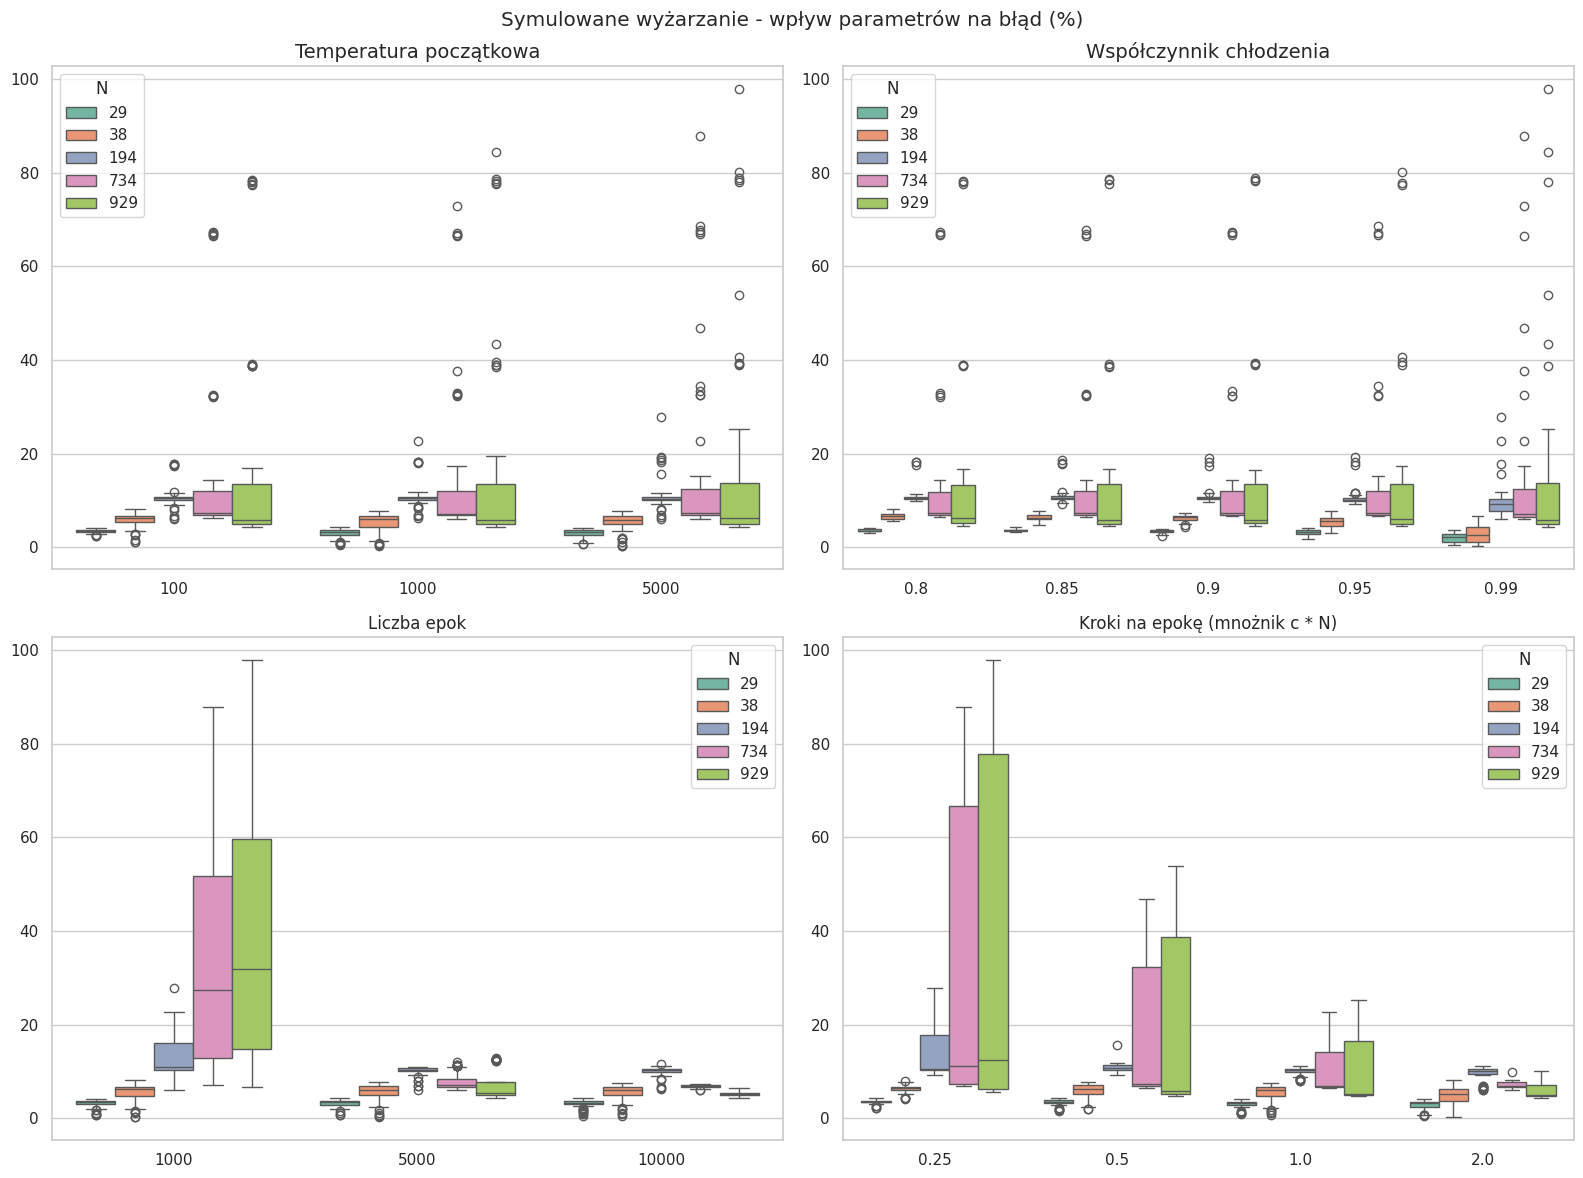

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Symulowane wyżarzanie - wpływ parametrów na błąd (%)")

sns.boxplot(data=saDF, x="initialTemperature", y="error", hue='N', ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Temperatura początkowa", fontsize=14)

sns.boxplot(data=saDF, x="alpha", y="error", hue='N', ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Współczynnik chłodzenia", fontsize=14)

sns.boxplot(data=saDF, x="epochs", y="error", hue='N', ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Liczba epok")

sns.boxplot(data=saDF, x="stepsMult", y="error", hue='N', ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Kroki na epokę (mnożnik c * N)")

for ax in axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Wnioski i optymalne parametry dla symolwanego wyżarzania

**Wnioski z powyższych wykresów:**
1. **Temperatura początkowa:** wyraźnie widać, że najmniejszy błąd jest przy wartości $1000$
2. **Współczynnik chłodzenia:** tutaj wyniki są podobne przez małe rozmiary grafów, jednakże można zauważyc, że wartość $0.99$ psuje wyniki, a przy wartości $0.95$ rozstrzał błędu jest najmniejszy
3. **Liczba epok i kroki na epokę:** przy liczbie epok znowu wyraźnie odznacza się wartość $10000$, przy której widać że algorytm działa najbardziej stabilnie. Ta sama sytuacja jest przy krokach na epokę dla największego grafu, widać że wartość największa daje najbardziej stabilne wyniki

**Ostateczne parametry dla symulowanego wyżarzania:**
* `initialTemperature` = $1000$
* `alpha` = $0.95$
* `epochs` = $10000$
* `stepsPerEpoch` = $2N$

# Analiza parametrów dla Tabu Search

**Wartości badane:**
* **Rozmiar listy tabu:** $\frac{1}{40}N, \frac{1}{20}N, \frac{1}{10}N, \frac{1}{5}N, \frac{1}{2}N$
* **Maksymalna liczba iteracji:** $1000, 5000, 10000$
* **Rozmiar próbki sąsiedztwa:** $\frac{1}{4}N, \frac{1}{2}N, N, 2N$

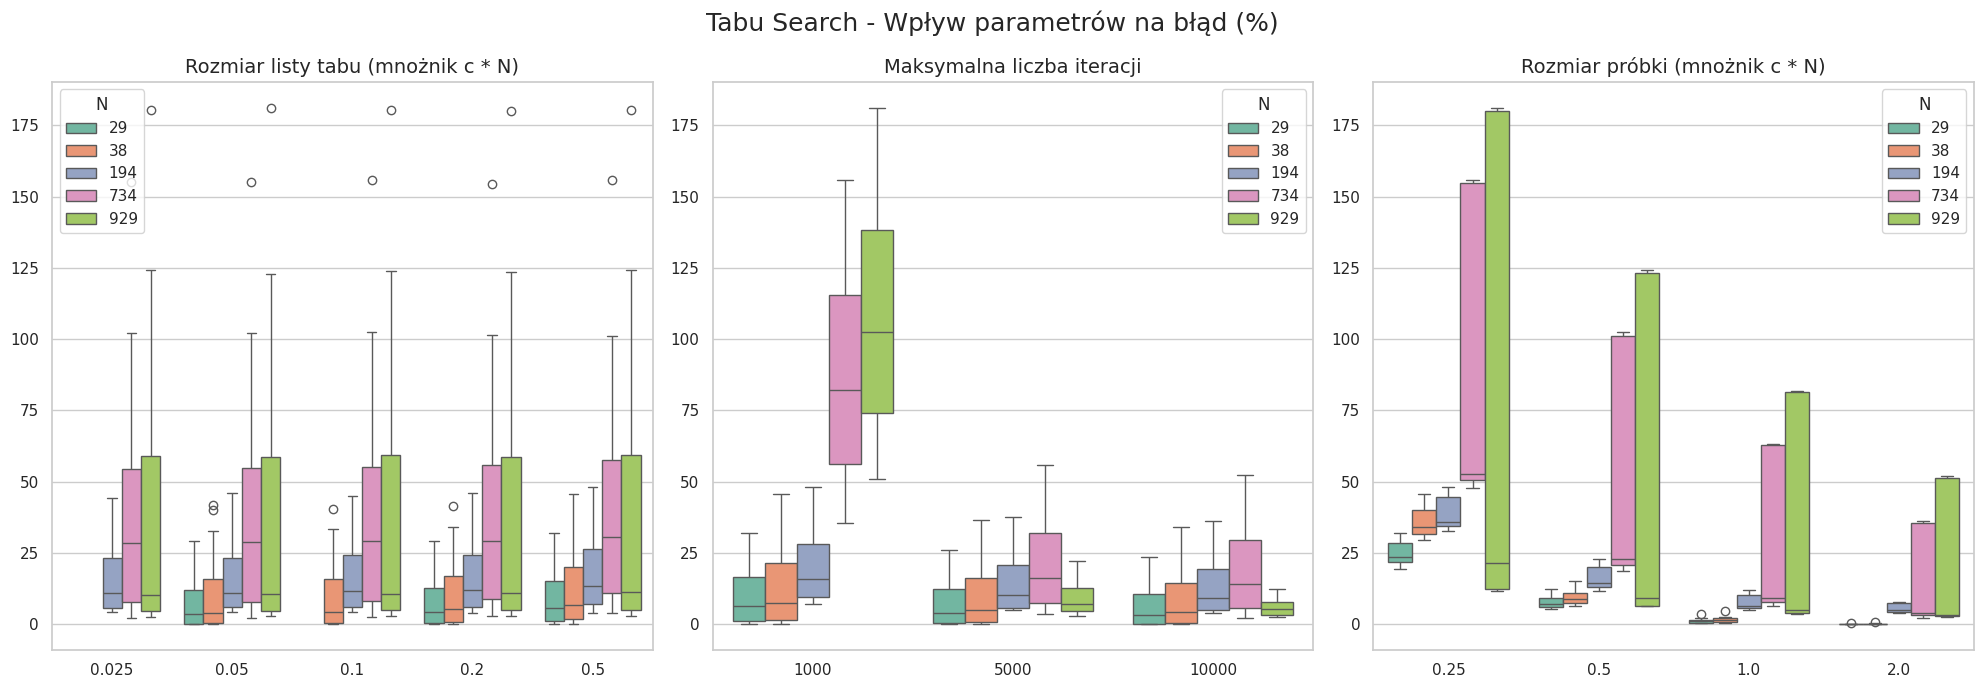

In [20]:
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 7))
fig2.suptitle('Tabu Search - Wpływ parametrów na błąd (%)', fontsize=18)

sns.boxplot(data=tsDF, x='tabuMult', y='error', hue='N', ax=axes2[0], palette="Set2")
axes2[0].set_title('Rozmiar listy tabu (mnożnik c * N)', fontsize=14)

sns.boxplot(data=tsDF, x='maxIterations', y='error', hue='N', ax=axes2[1], palette="Set2")
axes2[1].set_title('Maksymalna liczba iteracji', fontsize=14)

sns.boxplot(data=tsDF, x='sampleMult', y='error', hue='N', ax=axes2[2], palette="Set2")
axes2[2].set_title('Rozmiar próbki (mnożnik c * N)', fontsize=14)

for ax in axes2.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Wnioski i optymalne parametry dla Tabu Search

**Wnioski z powyższych wykresów:**
1. **Rozmiar listy tabu:** wyraźnie widać, że rozmiar listy nieznacznie wpływa na działanie algorytmu dla tych grafów wejściowych, można zauważyc, że tylko dla $\frac{1}{20}N$ wyniki są trochę stabilniejsze
2. **Maksymalna liczba iteracji:** błąd dla największego grafu dla wartości $10000$ jest zdecydowanie najmniejszy
3. **Rozmiar próbki:** widać podobieństwo do *kroków na epokę* w symulowanym wyżarzaniu. Błąd względny maleje z każdą wartościa, aż do $2N$, gdzie jest najmniejszy

**Ostateczne parametry dla Tabu Search:**
* `tabuSize` = $\frac{1}{20}N$
* `maxIterations` = $10000$
* `sampleSize` = $2N$